<a href="https://colab.research.google.com/github/Rick2898/Series_tiempo_prom_movil-/blob/main/ACTIVIDAD_1/Entrega.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# Implementacion de Holt Winters

#### Carlos Preciado
#### Jefferson Martinez
#### Ricardo Vargas

En el siguiente notebook se desarrolla la implementacion del mejor pronostico para los proximos seis meses con ayuda del modelo de holtwinters. La data para la implementacion es: la informacion de personas ocupadas en miles de personas para las principales 13 ciudades de Colombia en su archivo <code>datosEmpleo.xlsx</code>

## Carga de librerias y data

In [ ]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposicion 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import seaborn as sns




In [3]:

df_empleo= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleo.head()
df_empleo.shape

(222, 4)

In [4]:
df_empleo.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 222 entries, 2001-01-01 to 2019-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TD_13ciudades  222 non-null    float64
 1   Ocupados       222 non-null    float64
 2   Desocupados    222 non-null    float64
 3   Inactivos      222 non-null    float64
dtypes: float64(4)
memory usage: 8.7 KB


## Division train test

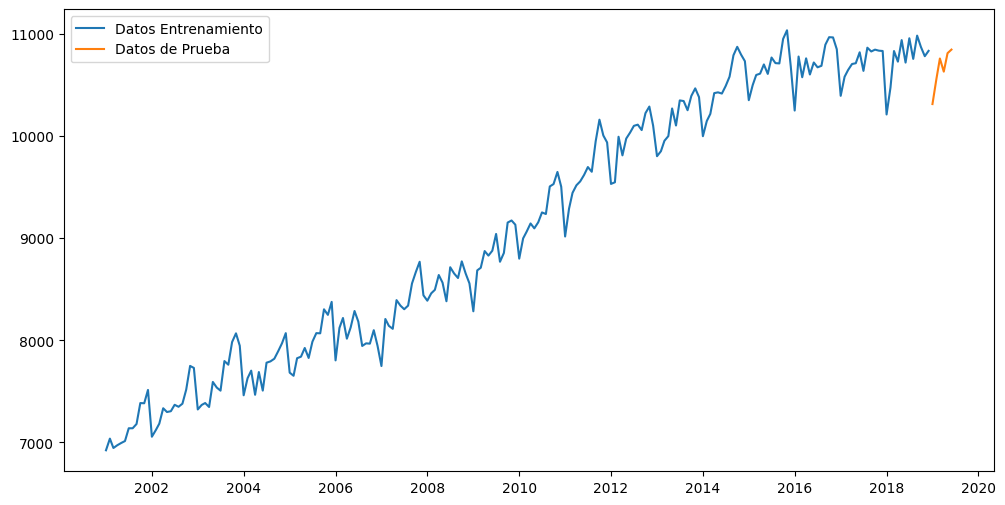

In [5]:
train_len = 216
train_td = df_empleo[["Ocupados"]][:train_len]
test_td  = df_empleo[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td,  label="Datos de Prueba")
plt.legend()
plt.show()

## Implementacion Holt Winters Aditivo

In [6]:
# ── Modelo Holt-Winters ADITIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend="add", seasonal="add"
)
ets_result = ets_model.fit()

# Pronósticos para 14 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_add = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10349.038256  10090.537075  10607.539437
2019-02-01    10624.647272  10350.485455  10898.809090
2019-03-01    10770.076785  10481.098911  11059.054659
2019-04-01    10786.211615  10483.138374  11089.284856
2019-05-01    10870.784042  10554.239833  11187.328251
2019-06-01    10828.720945  10499.253569  11158.188320


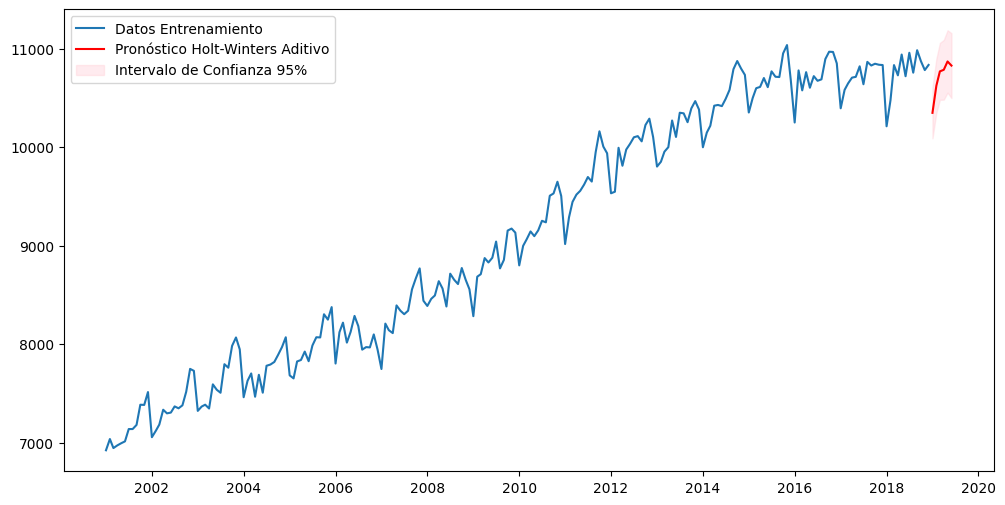

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'], label="Pronóstico Holt-Winters Aditivo", color='red')
plt.fill_between(preds_hw_add.index, preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()                 

In [7]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.beta, ets_result.gamma)

rmse_hw_add = np.sqrt(mean_squared_error(
    test_td, preds_hw_add['Point_forecast']
))
print(rmse_hw_add)

0.3532848405931927 3.532848405931927e-05 0.2970683164020024
74.40864219135457


## Implementacion Hotl Winters Multiplicativo

In [11]:
# ── Modelo Holt-Winters MULTIPLICATIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend=None, seasonal="mul"
)
ets_result = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast      lower_95      upper_95
2019-01-01    10325.781779  10099.156590  10548.704782
2019-02-01    10527.749215  10267.815499  10788.239674
2019-03-01    10611.310519  10321.956893  10898.946390
2019-04-01    10620.935104  10305.252598  10942.040487
2019-05-01    10689.617939  10356.102306  11047.881031
2019-06-01    10645.660988  10270.713595  11054.871035


c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.gamma)

rmse_hw_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_mul['Point_forecast']
))
print(rmse_hw_mul)

0.4350987524864517 0.1595868757426322
0.5895955647170604


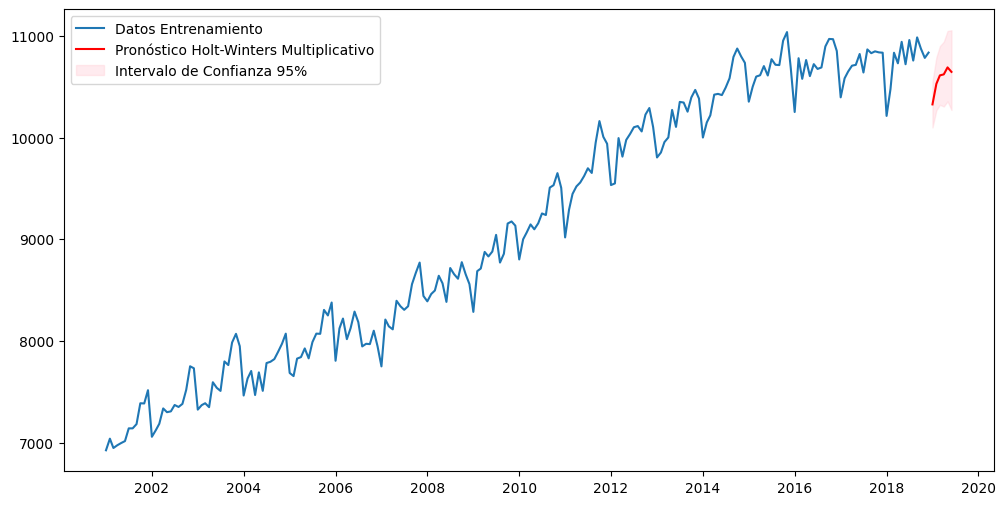

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_mul.index, preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()        

In [14]:

ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="mul", trend=None, seasonal="mul"
)
ets_result = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_mul_tend_NA_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_mul_tend_NA_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_mul_tend_NA_station_mul)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10324.805425  10065.528262  10599.477033
2019-02-01    10522.829105  10222.593680  10877.667594
2019-03-01    10595.191016  10264.304840  10956.595984
2019-04-01    10596.282255  10244.191990  11018.599822
2019-05-01    10671.641019  10255.948946  11116.466543
2019-06-01    10622.728256  10193.556212  11095.015894


In [16]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.gamma)

rmse_hw_error_mul_tend_NA_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_mul_tend_NA_station_mul['Point_forecast']
))
print(rmse_hw_error_mul_tend_NA_station_mul)

0.6251134101839402 3.748865898160598e-05
129.59199377333363


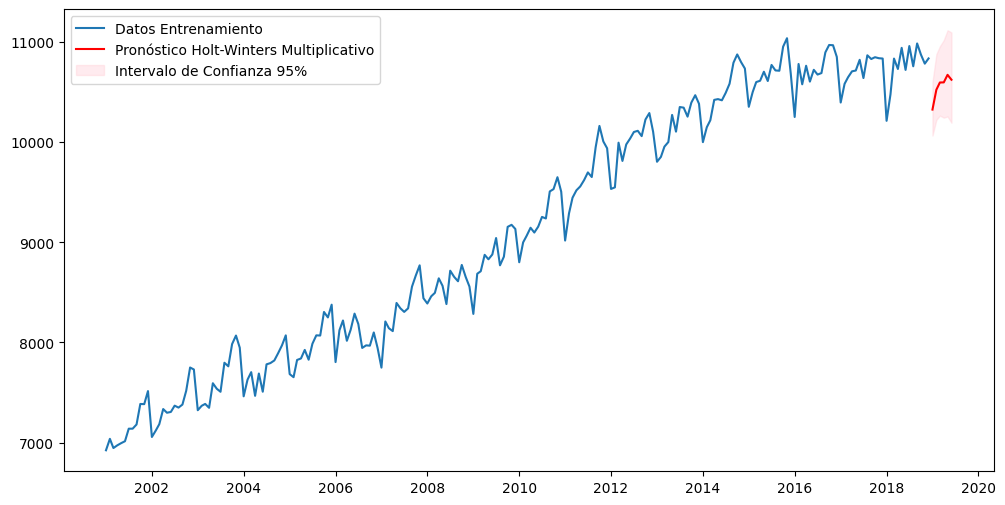

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_error_mul_tend_NA_station_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_error_mul_tend_NA_station_mul.index, preds_hw_error_mul_tend_NA_station_mul['lower_95'], preds_hw_error_mul_tend_NA_station_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()    

In [22]:
ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="mul", trend="add", seasonal="mul"
)
ets_result = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_mul_tend_add_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_mul_tend_add_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_mul_tend_add_station_mul)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10367.820011  10104.558327  10624.765595
2019-02-01    10581.945773  10277.139370  10885.380081
2019-03-01    10674.057740  10340.076637  11012.386350
2019-04-01    10694.674326  10317.017532  11090.979437
2019-05-01    10790.196544  10371.306671  11219.718618
2019-06-01    10760.456775  10318.835583  11218.028193


In [23]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.gamma)

rmse_hw_error_mul_tend_add_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_mul_tend_add_station_mul['Point_forecast']
))
print(rmse_hw_error_mul_tend_add_station_mul)

0.5594428857395526 4.405571142604474e-05
61.98851196075621
